# Fruit and Vegetable Fresh/Rotten Classification CNN.

## Tasks.
- Download, unzip and prepare dataset.
- Preprocess dataset.
- Train and test model.
- Implement Grading as set out in the case study.
- Export model.

In [54]:
import os

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import random
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

### Checking if the dataset exists, if it does not then download it from custom S3 bucket and prepare it.
For simplicity the kaggle dataset was uploaded to an S3 bucket for ease-of-access.

In [55]:
DATASET_DIRECTORY = '../dataset/Fruit And Vegetable Diseases Dataset'
BATCH_SIZE = 32
IMAGE_SIZE = (244, 244)
EPOCHS = 20
RAN_SEED = 181181 # Arbitrary seed for random number generation.

# Set seeds for random number generators.
tf.random.set_seed(RAN_SEED)
np.random.seed(RAN_SEED)
random.seed(RAN_SEED)

# Checking if dataset is present, if not then download and extract.
def check_dataset():
    if not os.path.exists(DATASET_DIRECTORY):
        print('Dataset not found, checking directory...')
        if not os.path.exists('../dataset'): os.mkdir('../dataset')
        if not os.path.isfile('../dataset/archive.zip'):
            print('Downloading archive...')
            import boto3
            from botocore import UNSIGNED
            from botocore.config import Config
            bucket_name = 'aai-university-content'
            endpoint = 'https://s3.fr-par.scw.cloud'
            file_key = 'archive.zip'
            local_file = '../dataset/archive.zip'
            s3 = boto3.client('s3',endpoint_url=endpoint,config=Config(signature_version=UNSIGNED))
            s3.download_file(bucket_name, file_key, local_file)
            print('Archive download complete.')

        print('Archive found, extracting archive...')
        from zipfile import ZipFile
        with ZipFile("../dataset/archive.zip", 'r') as zip_ref:
            zip_ref.extractall(path="../dataset")
        print('Archive extraction complete.')
        print('Removing archive...')
        os.remove('../dataset/archive.zip')
        print('Archive removed.')
    print('Dataset found.')

check_dataset()

Dataset found.


### Identify classes, images and labels from dataset.


In [56]:
dataset_img_paths = []
dataset_labels = []

# Identify the class names.
dataset_classes = sorted([x for x in os.listdir(DATASET_DIRECTORY) if os.path.isdir(os.path.join(DATASET_DIRECTORY, x))])

# Iterate through files to identify images and labels.
for label, dataset_class in enumerate(dataset_classes):
    directory = os.path.join(DATASET_DIRECTORY, dataset_class)
    for file_identifier in os.listdir(directory):
        if file_identifier.lower().endswith(('.jpg', '.jpeg', '.png')):
            dataset_img_paths.append(os.path.join(directory, file_identifier))
            dataset_labels.append(label)

print("Classes loaded: " + str(len(dataset_classes)))
print("Image locations loaded: " + str(len(dataset_img_paths)))
print("Labels loaded: " + str(len(dataset_labels)))

# Create simple table for displaying the total amount of data in each class.
dataset_label_ints = pd.Series(dataset_labels).value_counts().sort_index()
dataset_distribution = pd.DataFrame({
    "Class": dataset_classes,
    "Amount": dataset_label_ints.values
})
print("\nClass Totals: \n" + str(dataset_distribution))

Classes loaded: 28
Image locations loaded: 29277
Labels loaded: 29277

Class Totals: 
                   Class  Amount
0         Apple__Healthy    2438
1          Apple__Rotten    2925
2        Banana__Healthy    1999
3         Banana__Rotten    2797
4    Bellpepper__Healthy     611
5     Bellpepper__Rotten     591
6        Carrot__Healthy     619
7         Carrot__Rotten     579
8      Cucumber__Healthy     608
9       Cucumber__Rotten     593
10        Grape__Healthy     200
11         Grape__Rotten     200
12        Guava__Healthy     200
13         Guava__Rotten     200
14       Jujube__Healthy     200
15        Jujube__Rotten     200
16        Mango__Healthy    1813
17         Mango__Rotten    2247
18       Orange__Healthy    2075
19        Orange__Rotten    2186
20  Pomegranate__Healthy     200
21   Pomegranate__Rotten     200
22       Potato__Healthy     614
23        Potato__Rotten     584
24   Strawberry__Healthy    1603
25    Strawberry__Rotten    1596
26       Tomato__Health

### Split the data into training, validation and testing.

Using an 80/10/10 split of training, validation and testing data.

In [57]:
X_training, X_valTest, y_training, y_valTest = train_test_split(
    dataset_img_paths,
    dataset_labels,
    test_size=0.2,
    random_state=RAN_SEED
)

X_validation, X_testing, y_validation, y_testing = train_test_split(
    X_valTest,
    y_valTest,
    test_size=0.5,
    random_state=RAN_SEED
)

print(
    'Training Data:', str(len(X_training)),
    '\nValidation Data:', str(len(X_validation)),
    '\nTesting Data:', str(len(X_testing))
)

Training Data: 23421 
Validation Data: 2928 
Testing Data: 2928


### Image loading and dataset creation functions

In [58]:
def load_images(dataset_image_path, dataset_image_label):
    dataset_image = tf.io.read_file(dataset_image_path)
    dataset_image = tf.image.decode_image(dataset_image, channels=3, expand_animations=False)
    dataset_image = tf.image.resize(dataset_image, IMAGE_SIZE)
    #dataset_image = tf.image.convert_image_dtype(dataset_image, tf.float32)
    dataset_image = tf.cast(dataset_image, tf.float32) / 255.0
    return dataset_image, dataset_image_label

def create_tensorflow_dataset(dataset_image_path, dataset_image_label, train):
    tf_dataset = tf.data.Dataset.from_tensor_slices((dataset_image_path, dataset_image_label))
    tf_dataset = tf_dataset.map(load_images, num_parallel_calls=tf.data.AUTOTUNE)
    if train: tf_dataset = tf_dataset.shuffle(1000, RAN_SEED)
    tf_dataset = tf_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return tf_dataset

### Use above functions to instantiate the training, validation and testing datasets.
Also, an optional function to visualise the training data if line 18 uncommented.

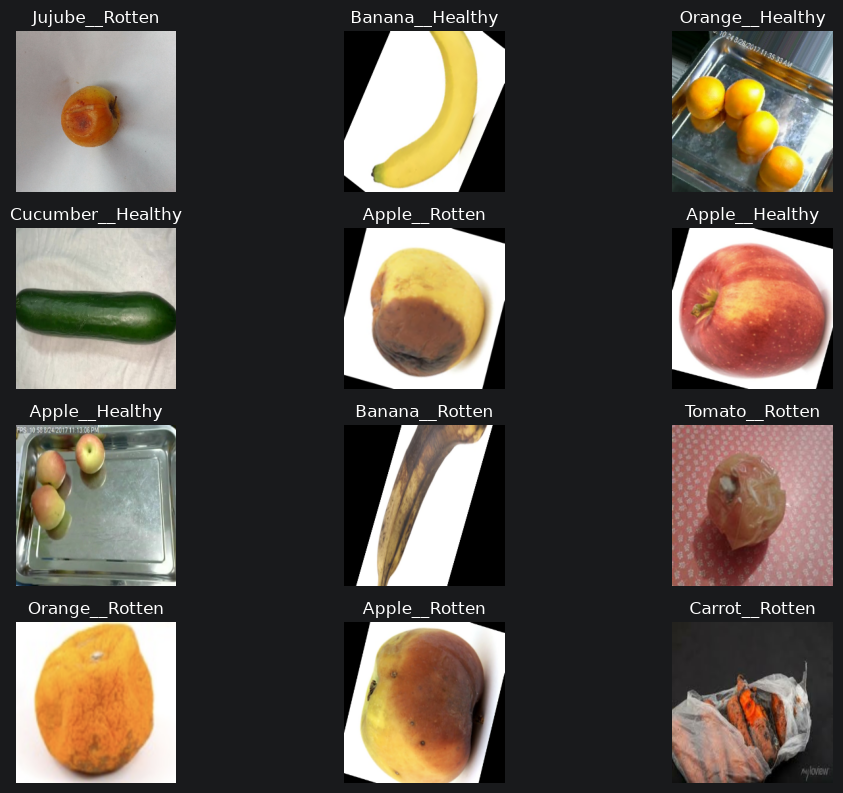

In [59]:
tf_training_dataset = create_tensorflow_dataset(X_training, y_training, True)
tf_validation_dataset = create_tensorflow_dataset(X_validation, y_validation,False)
tf_testing_dataset = create_tensorflow_dataset(X_testing, y_testing, False)

# Visualise training data
def vis_training_data():
    plt.figure(figsize=(10,10))
    for image, d_label in tf_training_dataset.take(1):
        for i in range(12):
            ax = plt.subplot(5, 3, i + 1)
            plt.imshow(image[i].numpy(), cmap='gray')
            plt.title(dataset_classes[d_label[i].numpy()])
            plt.axis('off')
    plt.tight_layout()
    plt.show()

# UNCOMMENT THIS TO RENDER VISUALISATION
vis_training_data()

### Create and Compile Keras Model

In [60]:
dataset_classes_amount = len(dataset_classes)
dataset_model_augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomZoom(0.1),
        tf.keras.layers.RandomRotation(0.1),
        tf.keras.layers.RandomFlip('horizontal')
    ]
)

dataset_model = models.Sequential(
    [
        layers.Input(shape=(244, 244, 3)),
        dataset_model_augmentation,
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(dataset_classes_amount, activation='softmax')
    ]
)

dataset_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'],)
dataset_model.summary()

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_12 (Sequential)      │ (None, 244, 244, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 244, 244, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 122, 122, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 122, 122, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_25 (MaxPooling2D) │ (None, 61, 61, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 61, 61, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_26 (MaxPooling2D) │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 30, 30, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_27 (MaxPooling2D) │ (None, 15, 15, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │    14,745,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 28)             │         7,196 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,141,468 (57.76 MB)

 Trainable params: 15,141,468 (57.76 MB)

 Non-trainable params: 0 (0.00 B)

### Fit the Model

In [61]:
dataset_model_callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, verbose=0, mode='auto', restore_best_weights=True),
    ModelCheckpoint(filepath='../models/fruit_cnn.keras', monitor='val_accuracy', save_best_only=True, mode='auto', verbose=0),
]
cnn_history = dataset_model.fit(tf_training_dataset, validation_data=tf_validation_dataset, epochs=EPOCHS, callbacks=dataset_model_callbacks, shuffle=False)
dataset_model.save('../models/trained_fruit_cnn.keras')

Epoch 1/20
247/732 ━━━━━━━━━━━━━━━━━━━━ 2:30 310ms/step - accuracy: 0.2242 - loss: 2.6002

W0000 00:00:1782887823.655418  191800 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile


464/732 ━━━━━━━━━━━━━━━━━━━━ 1:23 311ms/step - accuracy: 0.3142 - loss: 2.2941

W0000 00:00:1782887891.225986  191798 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile


732/732 ━━━━━━━━━━━━━━━━━━━━ 238s 323ms/step - accuracy: 0.3830 - loss: 2.0610 - val_accuracy: 0.6448 - val_loss: 1.2254
Epoch 2/20
247/732 ━━━━━━━━━━━━━━━━━━━━ 2:32 314ms/step - accuracy: 0.5786 - loss: 1.3852

...

732/732 ━━━━━━━━━━━━━━━━━━━━ 232s 316ms/step - accuracy: 0.9006 - loss: 0.3141 - val_accuracy: 0.9300 - val_loss: 0.2381
Epoch 20/20
247/732 ━━━━━━━━━━━━━━━━━━━━ 2:27 305ms/step - accuracy: 0.9019 - loss: 0.3092

W0000 00:00:1782892295.724921  273763 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile


464/732 ━━━━━━━━━━━━━━━━━━━━ 1:21 305ms/step - accuracy: 0.9044 - loss: 0.3054

W0000 00:00:1782892361.948254  273760 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile


732/732 ━━━━━━━━━━━━━━━━━━━━ 232s 316ms/step - accuracy: 0.9031 - loss: 0.3074 - val_accuracy: 0.9286 - val_loss: 0.2435
